**WORKFLOW 9: JOKE GENERATOR**  
# LangGraph: Memory and Persistance
  
Author: Nihit Kumar 

---
### THEORY 
**Persistance**: Persistance in Langgraph refers to the ability to save and restore the state of a workflow over time. This feature is used for **Fault Tolerance**.   

Persistence gives the feature to resume the workflow in case the workflow fails due to any reason. It stores the state of the workflow after every iteration of each node in a database. Therefore, it is possible to continue the workflow from where it stopped.  

**Checkpointer**: It divides the state of each point of the workflow in different checkpoints. Each superstep in a workflow is considered a checkpoint.  

**Threads**: Each thread is considered as a single conversation history in a Chatbot. We can say each workflow execution have a different thread id, which is considered as a unique key to that workflow.  

---

**Task**: Generate a joke using topic provided by the user. Explain the joke in next node. Using Persistence (RAM-based) we can save all the states in kernel memory.  

**States**:
- `topic` *str* : user input
- `joke` *str* : LLM Generated
- `explanation` *str* : LLM Generated


In [9]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver # Implementing RAM-Persistence
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv 

load_dotenv()

True

In [6]:
model = ChatOpenAI(model='gpt-5-nano')

In [5]:
class JokeState(TypedDict):
    topic: str
    joke: str
    explanation: str

In [7]:
def generate_joke(state: JokeState):
    prompt = f"Generate a joke on topic - {state['topic']}"

    response = model.invoke(prompt)

    return {'joke': response.content}

In [8]:
def explain_joke(state: JokeState):
    prompt = f"Explain the following joke \n {state['joke']}"

    response = model.invoke(prompt)

    return {'explanation': response.content}

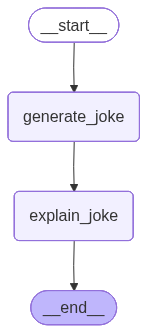

In [12]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('explain_joke', explain_joke)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'explain_joke')
graph.add_edge('explain_joke', END)

# implementing persisence using InMemorySaver class
checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)
workflow

In [ ]:
# Configuring thread id and executing the workflow
config1 = {'configurable': {'thread_id': '1'}}
workflow.invoke({'topic': 'pizza'}, config=config1)

{'topic': 'pizza',
 'joke': 'Here are a few pizza-themed jokes you can pick from:\n\n- Why did the pizza apply for a loan? It needed some dough.\n- What do you call a pizza with a big ego? A supreme.\n- How do you fix a broken pizza? With tomato paste.',
 'explanation': 'These jokes rely on wordplay (puns) using pizza terms that have double meanings.\n\n- Why did the pizza apply for a loan? It needed some dough.\n  - Explanation: “Dough” is the actual uncooked bread for pizza, but “dough” is also slang for money. The joke plays on both meanings at once.\n\n- What do you call a pizza with a big ego? A supreme.\n  - Explanation: “Supreme” is a common name for a multiple-topping pizza (the Supreme). It also means something that is the best or highest in rank, which ties to having a big ego.\n\n- How do you fix a broken pizza? With tomato paste.\n  - Explanation: “Paste” can mean glue, used to fix things. “Tomato paste” is a real pizza ingredient, so the line combines the idea of gluing wi

In [ ]:
# Get final state values
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Here are a few pizza-themed jokes you can pick from:\n\n- Why did the pizza apply for a loan? It needed some dough.\n- What do you call a pizza with a big ego? A supreme.\n- How do you fix a broken pizza? With tomato paste.', 'explanation': 'These jokes rely on wordplay (puns) using pizza terms that have double meanings.\n\n- Why did the pizza apply for a loan? It needed some dough.\n  - Explanation: “Dough” is the actual uncooked bread for pizza, but “dough” is also slang for money. The joke plays on both meanings at once.\n\n- What do you call a pizza with a big ego? A supreme.\n  - Explanation: “Supreme” is a common name for a multiple-topping pizza (the Supreme). It also means something that is the best or highest in rank, which ties to having a big ego.\n\n- How do you fix a broken pizza? With tomato paste.\n  - Explanation: “Paste” can mean glue, used to fix things. “Tomato paste” is a real pizza ingredient, so the line combines th

In [16]:
# Get intermidietary state values
# Convert it to a list since it is a generator object be default
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Here are a few pizza-themed jokes you can pick from:\n\n- Why did the pizza apply for a loan? It needed some dough.\n- What do you call a pizza with a big ego? A supreme.\n- How do you fix a broken pizza? With tomato paste.', 'explanation': 'These jokes rely on wordplay (puns) using pizza terms that have double meanings.\n\n- Why did the pizza apply for a loan? It needed some dough.\n  - Explanation: “Dough” is the actual uncooked bread for pizza, but “dough” is also slang for money. The joke plays on both meanings at once.\n\n- What do you call a pizza with a big ego? A supreme.\n  - Explanation: “Supreme” is a common name for a multiple-topping pizza (the Supreme). It also means something that is the best or highest in rank, which ties to having a big ego.\n\n- How do you fix a broken pizza? With tomato paste.\n  - Explanation: “Paste” can mean glue, used to fix things. “Tomato paste” is a real pizza ingredient, so the line combines t

In [18]:
config2 = {"configurable": {'thread_id': '2'}}
workflow.invoke({'topic': 'pasta'}, config=config2)

{'topic': 'pasta',
 'joke': 'Here are a few pasta-themed jokes:\n\n- What do you call fake spaghetti? An impasta.\n- Why did the spaghetti break up with the sauce? It found the relationship too clingy.\n- When the pasta started a band, it was called The Rolling Spoons.\n- I told my pasta a joke and it said, “That was pasta-bly hilarious!”',
 'explanation': 'These jokes are all built on wordplay (puns) that mix pasta terms with familiar phrases or pop-culture ideas. They often personify pasta and surprise you by swapping in pasta-related words.\n\n- What do you call fake spaghetti? An impasta.\n  - Explanation: A pun on "imposter." “Impasta” sounds like "im-pasta" and means fake spaghetti.\n\n- Why did the spaghetti break up with the sauce? It found the relationship too clingy.\n  - Explanation: Plays on relationship-benchword “clingy.” In pasta terms, sauce is the clingy partner that sticks to the pasta, so the breakup is funny because it’s a mechanical dating complaint applied to food

In [22]:
# We caan get the thread details for each workflow, using the thread_id/config
print("Pizza Jokes\n",workflow.get_state(config1).values['joke']) # Pizza related joke
print("\n\nPasta Jokes\n",workflow.get_state(config2).values['joke']) # Pasta related jokes


Pizza Jokes
 Here are a few pizza-themed jokes you can pick from:

- Why did the pizza apply for a loan? It needed some dough.
- What do you call a pizza with a big ego? A supreme.
- How do you fix a broken pizza? With tomato paste.


Pasta Jokes
 Here are a few pasta-themed jokes:

- What do you call fake spaghetti? An impasta.
- Why did the spaghetti break up with the sauce? It found the relationship too clingy.
- When the pasta started a band, it was called The Rolling Spoons.
- I told my pasta a joke and it said, “That was pasta-bly hilarious!”


# Time Travel
If we need to execute the workflow to debug where the issue actually popped up in a complex workflow, we can rerun the exact portion of the workflow.

In [47]:
# We are taking example of pizza joke

for i in list(workflow.get_state_history(config1)):
    print(i.next) # Get next node in the wf
    print(i.config['configurable']['checkpoint_id']) # Checkpint id of eaach node
    

()
1f1419ea-fd74-6b0c-8002-f12c5c6ed713
('explain_joke',)
1f1419ea-b167-66ac-8001-c1e8ca3bda88
('generate_joke',)
1f1419ea-5c44-62a2-8000-c62d586e2ef5
('__start__',)
1f1419ea-5c3a-665e-bfff-5584b5d0bb1e


In [50]:
# Get state for a particular checkpoint for a thread
# In this example, we took exactly the point where joke is not generated but we have the topic
workflow.get_state({'configurable':{'thread_id':'1','checkpoint_id': '1f1419ea-5c44-62a2-8000-c62d586e2ef5'}})


StateSnapshot(values={'topic': 'pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f1419ea-5c44-62a2-8000-c62d586e2ef5'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-04-26T18:35:06.693699+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1419ea-5c3a-665e-bfff-5584b5d0bb1e'}}, tasks=(PregelTask(id='abdb02b9-9bf4-9bd7-4016-0a06819a7c52', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': 'Here are a few pizza-themed jokes you can pick from:\n\n- Why did the pizza apply for a loan? It needed some dough.\n- What do you call a pizza with a big ego? A supreme.\n- How do you fix a broken pizza? With tomato paste.'}),), interrupts=())

In [51]:
# Executing the workflow from exactly this checkpoint
# When resuming a workflow, we should provide 'None' as the inital state.
# important paramter is config for resuming the workflow.

workflow.invoke(None, config={'configurable':{'thread_id':'1', 'checkpoint_id': '1f1419ea-5c44-62a2-8000-c62d586e2ef5'}})

{'topic': 'pizza',
 'joke': 'Why did the pizza go to the bank? It needed some dough. \n\nWant another pizza joke?',
 'explanation': "It's a pun. “Dough” can mean the money you’d need from a bank, and it also means the dough used to make pizza. The joke plays on treating a pizza like a person who needs money, which is silly and funny.\n\nWant another pizza joke? Here’s one:\n- How do you fix a broken pizza? With tomato paste."}

In [54]:
# We can see new branch getting created in the history.
# Since the thread_id remains the same, the new call is added in history
print(list(workflow.get_state_history(config1)))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the bank? It needed some dough. \n\nWant another pizza joke?', 'explanation': "It's a pun. “Dough” can mean the money you’d need from a bank, and it also means the dough used to make pizza. The joke plays on treating a pizza like a person who needs money, which is silly and funny.\n\nWant another pizza joke? Here’s one:\n- How do you fix a broken pizza? With tomato paste."}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f141a2d-9281-6bb2-8003-2e16eda8d10d'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-04-26T19:05:10.898782+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f141a2d-2145-6110-8002-180bb1e41f2e'}}, tasks=(), interrupts=()), StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the bank? It needed some dough. \n\nWant another pizza joke?'}, next=('explain_joke',

In [55]:
# For better understanding
for i in list(workflow.get_state_history(config1)):
    print(i.next) # Get next node in the wf
    print(i.config['configurable']['checkpoint_id']) 

()
1f141a2d-9281-6bb2-8003-2e16eda8d10d
('explain_joke',)
1f141a2d-2145-6110-8002-180bb1e41f2e
('generate_joke',)
1f141a2c-68eb-6897-8001-c20d7078284f
()
1f1419ea-fd74-6b0c-8002-f12c5c6ed713
('explain_joke',)
1f1419ea-b167-66ac-8001-c1e8ca3bda88
('generate_joke',)
1f1419ea-5c44-62a2-8000-c62d586e2ef5
('__start__',)
1f1419ea-5c3a-665e-bfff-5584b5d0bb1e


# Updating State
We can also update the state from in-between the workflow from any checkpoint id

In [57]:
workflow.update_state(
    {
        'configurable': {
            'thread_id': '1',
            'checkpoint_id': '1f1419ea-5c44-62a2-8000-c62d586e2ef5',
            'checkpoint_ns': ""
        }
    },
    {
        'topic':'samosa' # updating the state 'topic'
    }
)

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f141a3e-b6ef-6873-8001-add906e5bad8'}}

In [61]:

for i in list(workflow.get_state_history(config1)):
    print(i.values) # New checkpoint created will show topic as samosa
    print(i.next) # Get next node in the wf
    print(i.config['configurable']['checkpoint_id']) 

{'topic': 'samosa'}
('generate_joke',)
1f141a3e-b6ef-6873-8001-add906e5bad8
{'topic': 'pizza', 'joke': 'Why did the pizza go to the bank? It needed some dough. \n\nWant another pizza joke?', 'explanation': "It's a pun. “Dough” can mean the money you’d need from a bank, and it also means the dough used to make pizza. The joke plays on treating a pizza like a person who needs money, which is silly and funny.\n\nWant another pizza joke? Here’s one:\n- How do you fix a broken pizza? With tomato paste."}
()
1f141a2d-9281-6bb2-8003-2e16eda8d10d
{'topic': 'pizza', 'joke': 'Why did the pizza go to the bank? It needed some dough. \n\nWant another pizza joke?'}
('explain_joke',)
1f141a2d-2145-6110-8002-180bb1e41f2e
{'topic': 'pizza'}
('generate_joke',)
1f141a2c-68eb-6897-8001-c20d7078284f
{'topic': 'pizza', 'joke': 'Here are a few pizza-themed jokes you can pick from:\n\n- Why did the pizza apply for a loan? It needed some dough.\n- What do you call a pizza with a big ego? A supreme.\n- How do y

In [62]:
# Invoking the new state
# If we want to execute the samosa joke, we need to provide the new_checkpoint_id
# Changing the state (topic), creates a new branch in the workflow
# We need to ensure we are executing the correct checkpoint_id
# Pass None in the initial_state, and only pass the new config, with checkpoint_id
workflow.invoke(
    None,
    config={
        'configurable': {
            'thread_id': '1',
            'checkpoint_id': '1f141a3e-b6ef-6873-8001-add906e5bad8' # Provide the new checkpoint id (for samosa here)
        }
    }
)

{'topic': 'samosa',
 'joke': 'Here are a few samosa jokes you can pick from:\n\n- Why don’t samosas spill secrets? They’re wrapped up and keep the filling under wraps.\n- What do you call a samosa that tells jokes? A pocket comedian.\n- Samosa: the triangle that fits in your hand and somehow fills your heart.\n- I brought a samosa to the gym. It says it’s already shredded—wrapped and ready to dip!\n- What did the samosa say to the chutney? I’m stuffed, but I can still dip with you!',
 'explanation': 'These jokes mainly rely on wordplay and some light anthropomorphism of a samosa. They twist common phrases about wrappers, fillings, and dips to fit the samosa, plus a bit of shape and size humor.\n\n- Why don’t samosas spill secrets? They’re wrapped up and keep the filling under wraps.\nExplanation: “Wrap” refers to the pastry wrapper. “Under wraps” is a phrase meaning secret or concealed, and “filling” is the tasty stuff inside a samosa. The joke plays on both senses of “wrap/under wraps

In [64]:
# Checking the new history

for i in list(workflow.get_state_history(config1)):
    print(i.next) # Get next node in the wf
    print(i.config['configurable']['checkpoint_id']) 

()
1f141a4f-a63e-6a1d-8003-9eb7e4962d0a
('explain_joke',)
1f141a4f-3c2f-67ed-8002-ca47587f58fa
('generate_joke',)
1f141a3e-b6ef-6873-8001-add906e5bad8
()
1f141a2d-9281-6bb2-8003-2e16eda8d10d
('explain_joke',)
1f141a2d-2145-6110-8002-180bb1e41f2e
('generate_joke',)
1f141a2c-68eb-6897-8001-c20d7078284f
()
1f1419ea-fd74-6b0c-8002-f12c5c6ed713
('explain_joke',)
1f1419ea-b167-66ac-8001-c1e8ca3bda88
('generate_joke',)
1f1419ea-5c44-62a2-8000-c62d586e2ef5
('__start__',)
1f1419ea-5c3a-665e-bfff-5584b5d0bb1e
